In [1]:
# import python and pytorch libraries
from __future__ import absolute_import
from __future__ import print_function

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import codecs
from copy import deepcopy
import os
import pandas as pd
import numpy as np
from datetime import datetime
from pathlib import Path
import sys
import numpy as np
import logging
import tempfile
import shutil
import pickle
import platform
import json
from datetime import datetime
import random
from sklearn import metrics
import matplotlib.pyplot as plt
import itertools
import collections
from collections import defaultdict
import shap

In [3]:
import import_ipynb
from mimic_utils_text import InHospitalMortalityReader, Discretizer, Normalizer, read_chunk

importing Jupyter notebook from mimic_utils_text.ipynb


c:\Users\DAIMA Researcher\anaconda3\Lib\site-packages\nbformat\__init__.py:93: MissingIDFieldWarning: Code cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


In [4]:
LOGGER = logging.getLogger("LSTM")

LOGGER.setLevel(logging.INFO)
logging_format = logging.Formatter(
    "[%(asctime)s - %(filename)s:%(lineno)s - %(funcName)s() - %(levelname)s %(message)s"
)
ch = logging.StreamHandler()
ch.setFormatter(logging_format)
LOGGER.addHandler(ch)

In [5]:
date_today = datetime.today().strftime("%Y-%m-%d")
data_dir = "data/AKI/fts_extract_race_groups"
model_save_dir = f"data/models/{date_today}/{Path(data_dir).name}"
results_save_dir = f"data/results/{date_today}/{Path(data_dir).name}"
figure_dict = {"plotly": {}, "matplotlib": {}}
metrics_dict = {}
padding_num_features = 35  # 34 for default dataset

In [6]:
def list_to_str(l: list) -> list:
    new_list = []
    for item in l:
        if isinstance(item, list):
            new_list.append(list_to_str(item))
        elif isinstance(item, dict):
            new_list.append(dict_to_str(item))
        elif isinstance(item, np.generic):
            new_list.append(item.item())
    return new_list


def dict_to_str(d: dict) -> dict:
    for k, v in d.items():
        if isinstance(v, dict):
            dict_to_str(v)
        elif isinstance(v, list):
            d[k] = list_to_str(v)

        elif isinstance(v, np.generic):
            d[k] = v.item()
    return d

# Pytorch Dataset

In [7]:
# pad missing values in the nested lists with 0s
def pad_missing_value_with_zero(data):
    a1 = np.zeros((len(data), max([len(k) for k in data]), padding_num_features))  # 35
    for ctr, k in enumerate(data):
        # print(ctr, len(k), k)
        # Convert string representations of Boolean values to numerical values
        k = np.array([[1.0 if val == "True" else 0.0 if val == "False" else float(val) for val in row] for row in k])

        a1[ctr, : len(k), :] = k
    return a1

In [8]:
# pytroch class for reading data into batches
class MIMICDataset(Dataset):
    """
    Loads time series data into memory from a text file,
    split by newlines.
    """

    def __init__(self, reader, target_repl=False, batch_labels=False):
        self.data = []
        self.y = []
        N = reader.get_number_of_examples()
        print(f"Number of examples:{N}")
        # read data form cvs files
        ret = read_chunk(reader, N)
        # read into memory structured data X and labels y
        # print(ret)

        data = ret["X"]
        ts = ret["t"]
        labels = ret["y"]
        names = ret["name"]
        self.features = ret["header"]

        # print(data)

        # pad missing values in the list of arrays with 0s
        data = pad_missing_value_with_zero(data)

        self.data = np.array(data, dtype=np.float32)
        self.T = self.data.shape[1]

        if batch_labels:
            self.y = np.array([[l] for l in labels], dtype=np.float32)
        else:
            self.y = np.array(labels, dtype=np.float32)
        if target_repl:
            self.y = self._extend_labels(self.y)

    def _extend_labels(self, labels):
        # (B,)
        labels = labels.repeat(self.T, axis=1)  # (B, T)
        return labels

    def __len__(self):
        # overide len to get number of instances
        return len(self.data)

    def __getitem__(self, idx):
        # get features (physiological variables x) and label for a given instance index
        return self.data[idx], self.y[idx]

# Evaluation metrics
The main measure used are accuracy, ROC AUC and PR AUC.

In [9]:
# eval metrics
def print_metrics_binary(y_true, predictions, logger, verbose=1):
    predictions = np.array(predictions)
    if len(predictions.shape) == 1:
        predictions = np.stack([1 - predictions, predictions]).transpose((1, 0))
    cf = metrics.confusion_matrix(y_true, predictions.argmax(axis=1))
    if verbose:
        logger.info("confusion matrix:")
        logger.info(cf)
    cf = cf.astype(np.float32)

    acc = (cf[0][0] + cf[1][1]) / np.sum(cf)
    prec0 = cf[0][0] / (cf[0][0] + cf[1][0])
    prec1 = cf[1][1] / (cf[1][1] + cf[0][1])
    rec0 = cf[0][0] / (cf[0][0] + cf[0][1])
    rec1 = cf[1][1] / (cf[1][1] + cf[1][0])
    auroc = metrics.roc_auc_score(y_true, predictions[:, 1])

    (precisions, recalls, thresholds) = metrics.precision_recall_curve(y_true, predictions[:, 1])
    auprc = metrics.auc(recalls, precisions)
    minpse = np.max([min(x, y) for (x, y) in zip(precisions, recalls)])

    if verbose:
        logger.info("accuracy = {0:.3f}".format(acc))
        logger.info("precision class 0 = {0:.3f}".format(prec0))
        logger.info("precision class 1 = {0:.3f}".format(prec1))
        logger.info("recall class 0 = {0:.3f}".format(rec0))
        logger.info("recall class 1 = {0:.3f}".format(rec1))
        logger.info("AUC of ROC = {0:.3f}".format(auroc))
        logger.info("AUC of PRC = {0:.3f}".format(auprc))

    return {"acc": acc, "prec0": prec0, "prec1": prec1, "rec0": rec0, "rec1": rec1, "auroc": auroc, "auprc": auprc}

In [10]:
def performance_with_cutoff(y_test, pred_probabilities, verbose=1):
    # performance
    fpr, tpr, thresholds = metrics.roc_curve(y_test, pred_probabilities)
    # compute roc auc
    roc_auc = metrics.roc_auc_score(y_test, pred_probabilities, average="micro")
    # compute Precision_Recall curves
    precision, recall, _ = metrics.precision_recall_curve(y_test, pred_probabilities)
    # compute PR_AUC
    pr_auc = metrics.auc(recall, precision)

    # compute confusion matrix
    optimal_cut_off = round(thresholds[np.argmax(tpr - fpr)], 4)
    a = np.where(pred_probabilities > optimal_cut_off, 1, 0)
    brier = round(metrics.brier_score_loss(y_test, pred_probabilities, sample_weight=None, pos_label=None), 3)
    predictions = np.where(pred_probabilities > optimal_cut_off, 1, 0)
    matrix = metrics.confusion_matrix(y_test, a, labels=None, normalize=None)

    if verbose:
        LOGGER.info("confusion matrix after tuning with cutoff")
        LOGGER.info("Cut off: " + str(optimal_cut_off))
        LOGGER.info(matrix)
        LOGGER.info("accuracy with cutoff = {0:.3f}".format(metrics.accuracy_score(y_test, predictions)))

# Training
Here we define the model, loss and training loop. The model is an LSTM. 

In [11]:
# model
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        tag_size,
        hidden_size,
        feat_size,
        emb_size,
        bidirectional=False,
        dropout=0.2,
        aggregation_type="last_state",
    ):
        """
        constructor, here we define the hidden layers for our architecture
        """
        super().__init__()
        # define if the rnn will be bidirectional
        self.bidirectional = bidirectional
        # define the aggregation type of the features for the classifier for example, you can take the mean
        self.aggregation_type = aggregation_type
        self.encoder = nn.Linear(feat_size, emb_size, bias=True)
        # Create a (bidirectional) LSTM to encode sequence
        self.lstm = nn.LSTM(emb_size, hidden_size, batch_first=True, bidirectional=bidirectional)

        # The output of the LSTM doubles if we use a bidirectional encoder.
        encoding_size = hidden_size * 2 if bidirectional else hidden_size
        self.combination_layer = nn.Linear(encoding_size, encoding_size)

        # Create affine layer to project to the classes
        self.projection = nn.Linear(encoding_size, tag_size)
        # dropout layer for regularizetion of a sequence
        self.dropout_layer = nn.Dropout(p=dropout)
        self.relu = nn.ReLU()

    def forward(self, x, seq_mask=None, seq_len=None):
        # input size
        # [B, T, feat_size] batch, time and features
        # return unormalized probabilities (logits)
        # the loss will compute the sigmoid and negative log-likelihood
        # output size
        # [B, num_class] batch, and 1 class

        # [B, T, F] batch, time, features
        h1 = self.encoder(x)
        h1 = self.relu(h1)
        # [B, T, H] batch, time, hidden or hidden * 2
        outputs, (final, _) = self.lstm(h1)

        if self.aggregation_type == "mean":
            # mean over hidden states of LSTM
            outputs = self.dropout_layer(outputs)
            h = self.relu(self.combination_layer(outputs))
            # [B, H] batch, hidden
            h = h.mean(dim=1)  # mean over time dimension
        elif self.aggregation_type == "last_state":
            # last hidden state of the lstm or concat of bidirectional forward and backward states
            if self.bidirectional:
                h_T_fwd = final[0]  # lstm 1, last hidden state of forward lstm
                h_T_bwd = final[1]  # lstm 2. last hidden state of backward lstm
                # [B, H*2]
                h = torch.cat(
                    [h_T_fwd, h_T_bwd], dim=-1
                )  # concatenate the forward with the backward in the last dimension (feat)
            else:
                h = final[-1]
            h = self.relu(self.combination_layer(h))
            h = self.dropout_layer(h)
        # [B, H] # summary for each patient
        # [B, 1]
        logits = self.projection(h)

        return logits

In [12]:
# eval model
def eval_model(model, dataset, device):
    model.eval()
    sigmoid = nn.Sigmoid()
    with torch.no_grad():
        y_true = []
        predictions = []
        for data, labels in dataset:
            data = data.to(device)
            labels = labels.to(device)
            logits = model(data)
            probs = sigmoid(logits)
            predictions += [p.item() for p in probs]  # concatenate all predictions
            y_true += [y.item() for y in labels]  # concatenate all labels
    results = print_metrics_binary(y_true, predictions, LOGGER)
    performance_with_cutoff(y_true, predictions)

    return results, predictions, y_true

In [13]:
def generate_arg_summary(args):
    arg_detail = (
        "_dropout_"
        + str(args["dropout"])
        + ",batch_size_"
        + str(args["batch_size"])
        + ",lr_"
        + str(args["lr"])
        + ",epochs_"
        + str(args["epochs"])
    )
    return arg_detail

In [14]:
def train(args):
    mode = "train"
    hidden_size = args["dim"]
    dropout = args["dropout"]
    batch_size = args["batch_size"]
    learning_rate = args["lr"]
    num_epochs = args["epochs"]
    emb_size = args["emb_size"]
    aggregation_type = args["aggregation_type"]
    bidirectional_encoder = args["bidirectional"]
    seed = args["seed"]
    steps = args["steps"]
    data = args["data"]
    notes = args["notes"]
    timestep = args["timestep"]
    normalizer_state = args["normalizer_state"]

    if seed:
        torch.manual_seed(seed)
        np.random.seed(seed)
    device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
    LOGGER.info(f"Device: {device}")

    # define cvs data readers

    # if(notes != None):
    train_reader = InHospitalMortalityReader(
        dataset_dir=os.path.join(data, "train"),
        notes_dir=notes,
        listfile=os.path.join(notes, "train_listfile.csv"),
        period_length=48.0,
    )

    val_reader = InHospitalMortalityReader(
        dataset_dir=os.path.join(data, "train"),
        notes_dir=notes,
        listfile=os.path.join(notes, "val_listfile.csv"),
        period_length=48.0,
    )
    # else:
    #     train_reader = InHospitalMortalityReader(dataset_dir=os.path.join(data, 'train'),
    #                                          notes_dir=None,
    #                                          listfile=os.path.join(notes, 'train_listfile.csv'),
    #                                          period_length=48.0)

    #     val_reader = InHospitalMortalityReader(dataset_dir=os.path.join(data, 'train'),
    #                                         notes_dir=None,
    #                                         listfile=os.path.join(notes, 'val_listfile.csv'),
    #                                         period_length=48.0)

    train_dataset = MIMICDataset(train_reader, batch_labels=True)
    train_dl = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = MIMICDataset(val_reader, batch_labels=True)
    val_dl = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # [B, T, feat_size] batch, time, and num of variables
    feat_size = train_dataset.data.shape[-1]

    # Define the classification model
    model = LSTMClassifier(
        tag_size=1,  # binary
        feat_size=feat_size,
        hidden_size=hidden_size,
        emb_size=emb_size,
        bidirectional=bidirectional_encoder,
        dropout=dropout,
        aggregation_type=aggregation_type,
    )

    model = model.to(device)
    LOGGER.info(args)
    LOGGER.info(model)

    # Define optimizer
    optimizer = Adam(model.parameters(), lr=learning_rate)

    # define loss for binary classification
    criterion = nn.BCEWithLogitsLoss()

    # path to save model with extension .pt on disk
    args_detail = (
        "_dropout_"
        + str(args["dropout"])
        + ",batch_size_"
        + str(args["batch_size"])
        + ",lr_"
        + str(args["lr"])
        + ",epochs_"
        + str(args["epochs"])
    )
    best_val_auc = 0.0

    results = []

    step = 0
    num_batches = 0
    e_losses = []

    for epoch in range(num_epochs):
        loss_batch2 = 0.0
        model.train()
        for x, labels in train_dl:
            x = x.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            y_logits = model(x)
            loss = criterion(y_logits, labels)
            loss_batch2 += loss.item()  # keep track of loss
            loss.backward()
            optimizer.step()
            step += 1
            num_batches += 1

            # Every number of steps show the model loss
            if step % steps == 0:
                LOGGER.info("epoch (%d) step %d: training loss = %.2f" % (epoch, step, loss_batch2 / num_batches))
                e_losses.append(loss_batch2 / num_batches)

        metrics_results, _, _ = eval_model(model, val_dl, device)
        metrics_results["epoch"] = epoch
        # save results of current epoch
        results.append(metrics_results)

        LOGGER.info(metrics_results)

        # Model selection
        if metrics_results["auroc"] > best_val_auc:
            best_val_auc = metrics_results["auroc"]
            model_save_name2 = (Path(model_save_dir) / args_detail).with_suffix(".pth")
            model_save_name2.parent.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), str(model_save_name2))

    model_save_name1 = (Path(model_save_dir) / args_detail).with_suffix(".pth")
    model_save_name1.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), str(model_save_name1))

    plt.plot(e_losses)
    return results

In [15]:
# for plot name
# args_detail = args_detail(args)

In [16]:
# execute training
# define hyperparameters
args = {
    "dim": 35,  # 35
    "dropout": 0.2,
    "batch_size": 64,
    "lr": 1e-3,
    "epochs": 50,
    "emb_size": 35,  # 35
    "aggregation_type": "mean",
    "bidirectional": False,
    "seed": 42,
    "steps": 1000,  # print loss every num of steps
    "data": data_dir,  # path to MIMIC data
    "notes": data_dir,  # text not used in this model
    "timestep": 1.0,  # observations every hour
    "imputation": "previous",  # imputation method
    "normalizer_state": None,
}  # we use normalization config

[2024-12-13 22:16:04,943 - 585167952.py:22 - train() - INFO Device: cuda:0


InHospitalMortalityReader init completed
InHospitalMortalityReader init completed
Number of examples:51996
Reading chunk of size 51996
Number of examples:7018
Reading chunk of size 7018


[2024-12-13 22:37:08,199 - 585167952.py:71 - train() - INFO {'dim': 35, 'dropout': 0.2, 'batch_size': 64, 'lr': 0.001, 'epochs': 50, 'emb_size': 35, 'aggregation_type': 'mean', 'bidirectional': False, 'seed': 42, 'steps': 1000, 'data': 'data/AKI/fts_extract_race_groups', 'notes': 'data/AKI/fts_extract_race_groups', 'timestep': 1.0, 'imputation': 'previous', 'normalizer_state': None}
[2024-12-13 22:37:08,204 - 585167952.py:72 - train() - INFO LSTMClassifier(
  (encoder): Linear(in_features=35, out_features=35, bias=True)
  (lstm): LSTM(35, 35, batch_first=True)
  (combination_layer): Linear(in_features=35, out_features=35, bias=True)
  (projection): Linear(in_features=35, out_features=1, bias=True)
  (dropout_layer): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)
[2024-12-13 22:37:30,509 - 1116186297.py:8 - print_metrics_binary() - INFO confusion matrix:
[2024-12-13 22:37:30,519 - 1116186297.py:9 - print_metrics_binary() - INFO [[ 590 1597]
 [ 218 4613]]
[2024-12-13 22:37:30,566 - 111

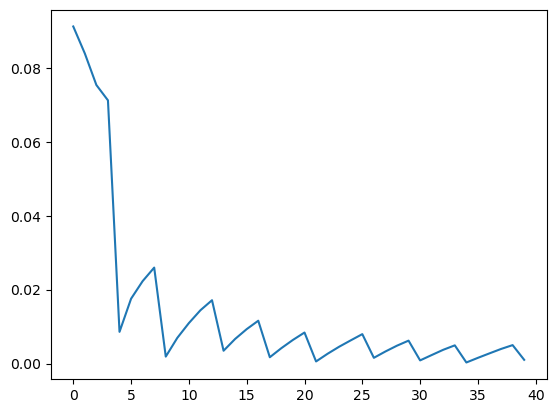

In [25]:
training_metrics = train(args)
metrics_dict["train"] = training_metrics

# Manual training

To explore in detail each step in the training process

In [16]:
# Manual Training
arg_mode = "train"
arg_hidden_size = args["dim"]
arg_dropout = args["dropout"]
arg_batch_size = args["batch_size"]
arg_learning_rate = args["lr"]
arg_num_epochs = args["epochs"]
arg_emb_size = args["emb_size"]
arg_aggregation_type = args["aggregation_type"]
arg_bidirectional_encoder = args["bidirectional"]
arg_seed = args["seed"]
arg_steps = args["steps"]
arg_data = args["data"]
arg_notes = args["notes"]
arg_timestep = args["timestep"]
arg_normalizer_state = args["normalizer_state"]

if arg_seed:
    torch.manual_seed(arg_seed)
    np.random.seed(arg_seed)
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
LOGGER.info(f"Device: {device}")

# define cvs data readers

# if(notes != None):
train_reader = InHospitalMortalityReader(
    dataset_dir=os.path.join(arg_data, "train"),
    notes_dir=arg_notes,
    listfile=os.path.join(arg_notes, "train_listfile.csv"),
    period_length=48.0,
)

val_reader = InHospitalMortalityReader(
    dataset_dir=os.path.join(arg_data, "train"),
    notes_dir=arg_notes,
    listfile=os.path.join(arg_notes, "val_listfile.csv"),
    period_length=48.0,
)

[2024-12-14 22:59:58,517 - 59702241.py:22 - <module>() - INFO Device: cuda:0


InHospitalMortalityReader init completed
InHospitalMortalityReader init completed


In [ ]:
# Instead of creating and obj MIMICDataset as follow
# train_dataset = MIMICDataset(train_reader, batch_labels=True)

# We'll run each step manually to understand the process
dataset_data = []
dataset_y = []
N = train_reader.get_number_of_examples()
print(f"Number of examples:{N}")

# read data form cvs files
ret = read_chunk(train_reader, N)

# read into memory structured data X and labels y
# print(ret)

data = ret["X"]
ts = ret["t"]
labels = ret["y"]
names = ret["name"]

In [ ]:
# Check the data
len(data[0][0])

In [ ]:
def convert_datetime_columns(data, datetime_columns):
    for col in datetime_columns:
        data[:, col] = pd.to_datetime(data[:, col], errors="coerce").astype(np.int64) // 10**9
    return data


def pad_missing_value_with_zero_modified(data):
    # Assuming data is a NumPy array
    data = np.where(data == "", "0", data)  # Replace empty strings with '0'
    data = np.where(data == "?", "0", data)  # Replace '?' with '0'

In [ ]:
# datetime_columns = [11, 16, 17, 28]

# data_copy = data

# # Process each item in the list
# for i in range(len(data_copy)):
#     # Convert datetime columns to Unix timestamps
#     data_copy[i] = convert_datetime_columns(data_copy[i], datetime_columns)
#     # Pad missing values with zero
#     data_copy[i] = pad_missing_value_with_zero(data_copy[i])

In [ ]:
# pad missing values in the list of arrays with 0s
# data = pad_missing_value_with_zero(data)
# pad_a1 = np.zeros((len(data), max([len(k) for k in data]), 72))  # 35
# print(pad_a1.shape)

In [ ]:
# for ctr, k in enumerate(data):
#     # print(ctr, len(k), k)
#     # Filter out non-numeric values
#     k = [item for item in k if isinstance(item, (int, float))]
#     if len(k) > 0:
#         print("continue")
#         pad_a1[ctr, : len(k), :] = np.array(k).reshape(-1, 72)

In [ ]:
# pad_a1[0][0]

In [ ]:
# dataset_data = np.array(data, dtype=np.float32)
# dataset_T = dataset_data.shape[1]

# if batch_labels:
#     dataset_y = np.array([[l] for l in labels], dtype=np.float32)
# else:
#     dataset_y = np.array(labels, dtype=np.float32)
# if target_repl:
#     dataset_y = dataset__extend_labels(dataset_y)

In [17]:
# for plot name
args_detail = generate_arg_summary(args)

# Test
Use the last trained model or the best validation model and run in test.
Also use calibration curves.

In [ ]:
# test


def test(args):
    # define trainning and validation datasets
    mode = "test"
    hidden_size = args["dim"]
    dropout = args["dropout"]
    batch_size = args["batch_size"]
    emb_size = args["emb_size"]
    best_model = args["best_model"]
    data = args["data"]
    notes = args["notes"]
    timestep = args["timestep"]
    aggregation_type = args["aggregation_type"]
    bidirectional_encoder = args["bidirectional"]
    device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
    # 1. Get a unique working directory

    test_reader = InHospitalMortalityReader(
        dataset_dir=os.path.join(data, "test"),
        notes_dir=notes,
        listfile=os.path.join(notes, "test_listfile.csv"),
        period_length=48.0,
    )

    # Read data
    test_dataset = MIMICDataset(test_reader, batch_labels=True)
    test_dl = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    # [B, M, feat_size]
    feat_size = test_dataset.data.shape[-1]

    # Define the classification model.
    model = LSTMClassifier(
        tag_size=1,  # binary
        feat_size=feat_size,
        hidden_size=hidden_size,
        emb_size=emb_size,
        bidirectional=bidirectional_encoder,
        dropout=dropout,
        aggregation_type=aggregation_type,
    )
    # load trained model from file
    model.load_state_dict(torch.load(best_model))
    LOGGER.info(model)
    model = model.to(device)

    metrics_results, pred_probs, y_true = eval_model(model, test_dl, device)
    return metrics_results, pred_probs, y_true

In [ ]:
args_detail

In [ ]:
# Run test on saved model latest_classifier
args = {
    "best_model": str((Path(model_save_dir) / args_detail).with_suffix(".pth")),
    "dim": 35,  # 35
    "dropout": 0.2,
    "batch_size": 16,
    "emb_size": 35,  # 35
    "aggregation_type": "mean",
    "bidirectional": False,
    "data": data_dir,  # path to data
    "notes": data_dir,  # text not used in this model
    "timestep": 1.0,
    "imputation": "previous",
    "normalizer_state": None,
}
print("Result of latest_classifier")
metrics_results, pred_probs, y_true = test(args)
metrics_dict["test_latest"] = metrics_results

In [ ]:
# Run test on saved model best_classifier
# remember to use the same hyperparameters as in training
args = {
    "best_model": str((Path(model_save_dir) / args_detail).with_suffix(".pth")),
    "dim": 35,  # 35
    "dropout": 0.2,
    "batch_size": 16,
    "emb_size": 35,  # 35
    "aggregation_type": "mean",
    "bidirectional": False,
    "data": data_dir,  # path to data
    "notes": data_dir,  # the code ignores the text
    "timestep": 1.0,
    "imputation": "previous",
    "normalizer_state": None,
}
print("Result of best_classifier")
metrics_results, pred_probs, y_true = test(args)
metrics_dict["test_best"] = metrics_results

# Plot

In [ ]:
# Figures ROC and calibration curve
import matplotlib.pyplot as plt
import sys
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.transforms as mtransforms
import pickle
from sklearn import metrics
import pandas as pd

In [ ]:
# roc curve
lstm_fpr, lstm_tpr, lstm_thresholds = metrics.roc_curve(y_true, pred_probs)

# plot the roc curve for the model
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

ax.set_ylim(0.0, 1.0)
ax.set_xlim(0.0, 1.0)
ax.plot(lstm_fpr, lstm_tpr, marker=".", label="LSTM_feat", color="darkorange")
ax.plot([0, 1], [0, 1], color="navy", linestyle="--", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
figure_dict["matplotlib"]["roc_curve"] = fig
fig.tight_layout()

In [ ]:
# pr curve
lstm_precision, lstm_recall, _ = metrics.precision_recall_curve(y_true, pred_probs)

# plot the precision-recall curves
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.plot([0, 1], [1, 0], linestyle="--", label="Random")
ax.plot(lstm_recall, lstm_precision, marker=".", label="LSTM_feat")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
figure_dict["matplotlib"]["pr_curve"] = fig
fig.tight_layout()

In [ ]:
# calibration curve
lstm_y, lstm_x = calibration_curve(y_true, pred_probs, n_bins=10)

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_ylim(0.0, 1.0)
ax.set_xlim(0.0, 1.0)
ax.plot(lstm_x, lstm_y, marker="^", linestyle="", markersize=7, label="LSTM_feat", color="darkorange")

ax.plot([0, 1], [0, 1], color="navy", linestyle="--", label="Random")

ax.set_xlabel("Mean predicted value")
ax.set_ylabel("Fraction of positives")
ax.legend()
figure_dict["matplotlib"]["calibration_curve"] = fig
fig.show()

# Explainability

## SHAP

In [18]:
model_path = 'data/models/2024-12-13/fts_extract_race_groups'

In [19]:
# Run test on saved model best_classifier
# remember to use the same hyperparameters as in training
args = {
    "best_model": str((Path(model_path) / args_detail).with_suffix(".pth")),
    "dim": 35,  # 35
    "dropout": 0.2,
    "batch_size": 16,
    "emb_size": 35,  # 35
    "aggregation_type": "mean",
    "bidirectional": False,
    "data": data_dir,  # path to data
    "notes": data_dir,  # the code ignores the text
    "timestep": 1.0,
    "imputation": "previous",
    "normalizer_state": None,
}

args

{'best_model': 'data\\models\\2024-12-13\\fts_extract_race_groups\\_dropout_0.2,batch_size_64,lr_0.pth',
 'dim': 35,
 'dropout': 0.2,
 'batch_size': 16,
 'emb_size': 35,
 'aggregation_type': 'mean',
 'bidirectional': False,
 'data': 'data/AKI/fts_extract_race_groups',
 'notes': 'data/AKI/fts_extract_race_groups',
 'timestep': 1.0,
 'imputation': 'previous',
 'normalizer_state': None}

In [ ]:
# Explain

# define trainning and validation datasets
mode = "test"
hidden_size = args["dim"]
dropout = args["dropout"]
batch_size = args["batch_size"]
emb_size = args["emb_size"]
best_model = args["best_model"]
data = args["data"]
notes = args["notes"]
timestep = args["timestep"]
aggregation_type = args["aggregation_type"]
bidirectional_encoder = args["bidirectional"]
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

# 1. Get a unique working directory
train_reader = InHospitalMortalityReader(
    dataset_dir=os.path.join(data, "train"),
    notes_dir=notes,
    listfile=os.path.join(notes, "train_listfile.csv"),
    period_length=48.0,
)

test_reader = InHospitalMortalityReader(
    dataset_dir=os.path.join(data, "test"),
    notes_dir=notes,
    listfile=os.path.join(notes, "test_listfile.csv"),
    period_length=48.0,
)

## Read data
train_dataset = MIMICDataset(train_reader, batch_labels=True)
train_dl = DataLoader(train_dataset, batch_size=100, shuffle=False)

test_dataset = MIMICDataset(test_reader, batch_labels=True)
test_dl = DataLoader(test_dataset, batch_size=100, shuffle=False)
# [B, M, feat_size]
feat_size = test_dataset.data.shape[-1]

InHospitalMortalityReader init completed
InHospitalMortalityReader init completed
Number of examples:51996
Reading chunk of size 51996
Number of records with more than 48 hours: 434
Number of examples:6368
Reading chunk of size 6368
Number of records with more than 48 hours: 56


In [106]:
# train_reader._period_length

train_dataset.features
# train_dataset.data.shape
# train_dataset.T
# train_dataset.y

['Hours',
 'aniongap_avg',
 'bicarbonate_avg',
 'bun_avg',
 'chloride_avg',
 'creat',
 'diasbp_mean',
 'glucose_avg',
 'heartrate_mean',
 'hematocrit_avg',
 'hemoglobin_avg',
 'potassium_avg',
 'resprate_mean',
 'sodium_avg',
 'spo2_mean',
 'sysbp_mean',
 'uo_rt_12hr',
 'uo_rt_24hr',
 'uo_rt_6hr',
 'wbc_avg',
 'sedative',
 'vasopressor',
 'vent',
 'anchor_age',
 'F',
 'M',
 'white_group',
 'black_african_group',
 'asian_group',
 'hispanic_group',
 'unknown_group',
 'native_group',
 'other_group',
 'ELECTIVE',
 'URGENT']

In [79]:
# Define the classification model.
model = LSTMClassifier(
    tag_size=1,  # binary
    feat_size=feat_size,
    hidden_size=hidden_size,
    emb_size=emb_size,
    bidirectional=bidirectional_encoder,
    dropout=dropout,
    aggregation_type=aggregation_type,
)

# load trained model from file
model.load_state_dict(torch.load(best_model))
LOGGER.info(model)
model = model.to(device)

[2024-12-15 00:07:20,806 - 2217917587.py:14 - <module>() - INFO LSTMClassifier(
  (encoder): Linear(in_features=35, out_features=35, bias=True)
  (lstm): LSTM(35, 35, batch_first=True)
  (combination_layer): Linear(in_features=35, out_features=35, bias=True)
  (projection): Linear(in_features=35, out_features=1, bias=True)
  (dropout_layer): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)


In [75]:
batch = next(iter(train_dl))
print(f'Size of the batch: {len(batch[0])}')

data, labels = batch
data = data.to(device)
background = data[:100]
test_data = data[:10]

Size of the batch: 100


In [78]:
print("Background data shape:", background.shape)
print("Test data shape:", test_data.shape)

Background data shape: torch.Size([100, 144, 35])
Test data shape: torch.Size([10, 144, 35])


### DeepExplainer

In [81]:
explainer = shap.DeepExplainer(model, background)
# shap_values = e.shap_values(test_data)

Error presented when running the next cell:

* `RuntimeError: cudnn RNN backward can only be called in training mode:` SHAP needs the model to be in training mode for proper gradient computation during the attribution process.

In [82]:
shap_values = explainer.shap_values(test_data)

RuntimeError: cudnn RNN backward can only be called in training mode

Solutions:
1. Set the Model to Training Mode. model.train() before and model.eval() after it.

In [85]:
model.train()
shap_values = explainer.shap_values(test_data)
model.eval()

AssertionError: The SHAP explanations do not sum up to the model's output! This is either because of a rounding error or because an operator in your computation graph was not fully supported. If the sum difference of %f is significant compared to the scale of your model outputs, please post as a github issue, with a reproducible example so we can debug it. Used framework: pytorch - Max. diff: 21.774979603997735 - Tolerance: 0.01

The Above cell cause the next one:
* `AssertionError: The SHAP explanations do not sum up to the model's output! This is either because of a rounding error or because an operator in your computation graph was not fully supported. If the sum difference of %f is significant compared to the scale of your model outputs, please post as a github issue, with a reproducible example so we can debug it. Used framework: pytorch - Max. diff: 21.42269716959757 - Tolerance: 0.01`

In [86]:
# check_additivity = False - To allow minor discrepancies in the sum
shap_values = explainer.shap_values(test_data, check_additivity=False)

In [ ]:
print(f' Shape of test data: {test_data.shape}')
print(f' Shape of shap values: {shap_values.shape}')

shap_values_squeezed = shap_values.squeeze(-1)
print(f' Shape of shap values squeezed: {shap_values_squeezed.shape}')

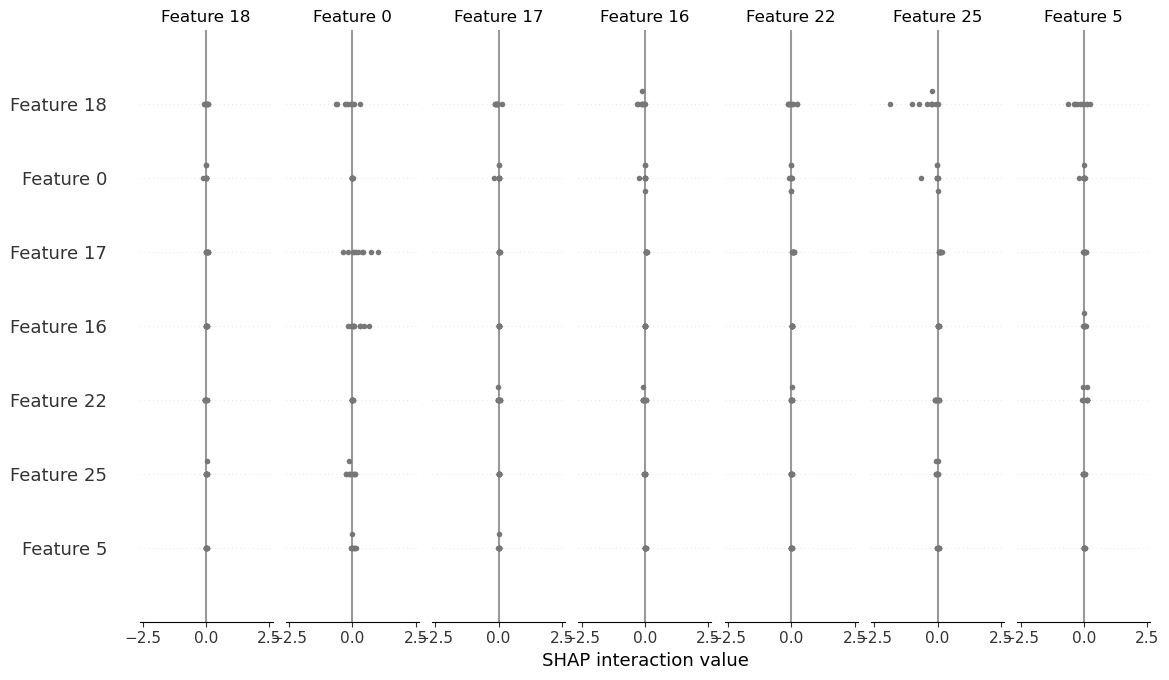

In [118]:
shap.summary_plot(shap_values_squeezed, test_data)

In [128]:
# shap.dependence_plot(shap_values_squeezed, test_data)
explainer = shap.DeepExplainer(model, background)

model.train()
shap_values = explainer.shap_values(test_data)
model.eval()

shap_values = explainer.shap_values(test_data, check_additivity=False)
shap_values_squeezed = shap_values.squeeze(-1)
shap.plots.heatmap(shap_values_squeezed)

AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [142]:
train_dataset.features

['Hours',
 'aniongap_avg',
 'bicarbonate_avg',
 'bun_avg',
 'chloride_avg',
 'creat',
 'diasbp_mean',
 'glucose_avg',
 'heartrate_mean',
 'hematocrit_avg',
 'hemoglobin_avg',
 'potassium_avg',
 'resprate_mean',
 'sodium_avg',
 'spo2_mean',
 'sysbp_mean',
 'uo_rt_12hr',
 'uo_rt_24hr',
 'uo_rt_6hr',
 'wbc_avg',
 'sedative',
 'vasopressor',
 'vent',
 'anchor_age',
 'F',
 'M',
 'white_group',
 'black_african_group',
 'asian_group',
 'hispanic_group',
 'unknown_group',
 'native_group',
 'other_group',
 'ELECTIVE',
 'URGENT']

c:\Users\DAIMA Researcher\anaconda3\Lib\site-packages\shap\explainers\_deep\deep_pytorch.py:243: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f'unrecognized nn.Module: {module_type}')


Shape of SHAP values: (144, 35)


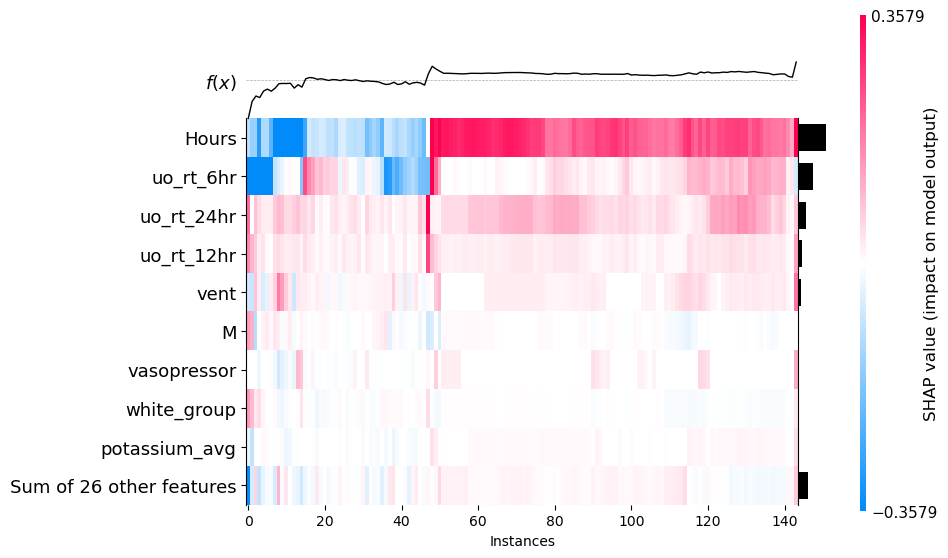

<Axes: xlabel='Instances'>

In [143]:
import shap
import torch

# Ensure model is in evaluation mode
model.eval()

# Disable cuDNN for RNN if necessary
torch.backends.cudnn.enabled = False

# Explaining predictions using SHAP DeepExplainer without additivity check
explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(test_data, check_additivity=False)

# If shap_values is a list, extract the first element (assuming it's the relevant output)
shap_values = shap_values[0]  # Adjust this if needed for multi-output models

# Squeeze the SHAP values if necessary
shap_values_squeezed = shap_values.squeeze(-1)  # Assuming you want to remove singleton dimensions

print(f"Shape of SHAP values: {shap_values_squeezed.shape}")


# Wrap the SHAP values in a shap.Explanation object for plotting
shap_values_explanation = shap.Explanation(values=shap_values_squeezed, 
                                           data=test_data, 
                                        #    feature_names=[f"Feature {i}" for i in range(shap_values_squeezed.shape[1])]
                                           feature_names=train_dataset.features)

# Plot the heatmap of the SHAP values
shap.plots.heatmap(shap_values_explanation)


[2024-12-14 21:43:23,617 - 3515241790.py:7 - <module>() - ERROR Error computing SHAP
Traceback (most recent call last):
  File "C:\Users\DAIMA Researcher\AppData\Local\Temp\ipykernel_28532\3515241790.py", line 3, in <module>
    shap_values = e.shap_values(test_data)
                  ^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\DAIMA Researcher\anaconda3\Lib\site-packages\shap\explainers\_deep\__init__.py", line 159, in shap_values
    return self.explainer.shap_values(X, ranked_outputs, output_rank_order, check_additivity=check_additivity)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\DAIMA Researcher\anaconda3\Lib\site-packages\shap\explainers\_deep\deep_pytorch.py", line 186, in shap_values
    sample_phis = self.gradient(feature_ind, joint_x)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\DAIMA Researcher\anaconda3\Lib\site-packages\shap\explainers\_deep\deep_pytorch.py", line 11

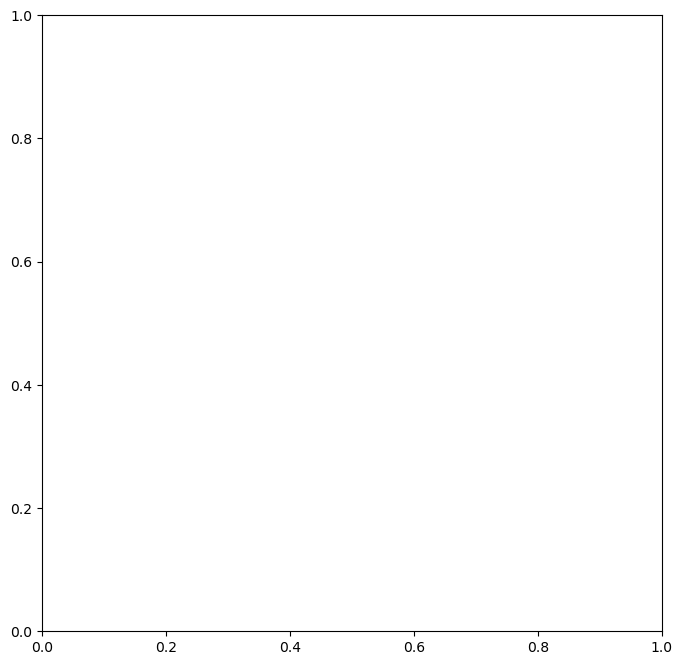

In [113]:
try:
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    shap_values = e.shap_values(test_data)
    shap.summary_plot(shap_values, test_data, feature_names=test_dataset.features, show=False, ax=ax)
    fig.tight_layout()
except:
    LOGGER.exception("Error computing SHAP")

### GradientExplainer

## LIME

In [26]:
!pip install lime

In [33]:
# Current function use to train a model
# metrics_results, pred_probs, y_true = eval_model(model, test_dl, device)

In [82]:
# Get a single batch from the test data loader
single_batch = next(iter(test_dl))
single_batch[0].shape

torch.Size([16, 96, 35])

In [83]:
num_batches = len(test_dl)
print(f'The number of batches in test_dl is: {num_batches}')

The number of batches in test_dl is: 398


In [ ]:
# Extract a single instance from the batch
single_instance, single_label = single_batch[0][0], single_batch[1][0]

# Print the instance and its label
print(f'Shape of the instance: {single_instance.shape}. Length of the shape: {len(single_instance.shape)}')
print(single_instance)
print(single_label)

In [29]:
feature_names = [
    'Hours','aniongap_avg',
    'bicarbonate_avg','bun_avg','chloride_avg','creat','diasbp_mean','glucose_avg',
    'heartrate_mean','hematocrit_avg','hemoglobin_avg','potassium_avg','resprate_mean',
    'sodium_avg','spo2_mean','sysbp_mean','uo_rt_12hr','uo_rt_24hr','uo_rt_6hr','wbc_avg',
    'sedative','vasopressor','vent','anchor_age','F','M',
    'white_group','black_african_group','asian_group','hispanic_group','unknown_group','native_group',
    'other_group','ELECTIVE','URGENT',
]

In [54]:
def flatten_timeseries( X):
    """
    Flatten time series data
    
    Parameters:
    - X: Time series data (batch of samples)
    
    Returns:
    - Flattened data
    """
    # Handle different input shapes
    if len(X.shape) == 3:
        # (batch_size, time_steps, features)
        return X.reshape(X.shape[0], -1)
    elif len(X.shape) == 4:
        # (batch_size, channels, time_steps, features)
        return X.reshape(X.shape[0], -1)
    return X

In [66]:
# Prepare the data for LIME
reference_data = []
reference_labels = []

count = 0;

# Iterate through data loader to collect reference samples
for batch_idx, (inputs, labels) in enumerate(train_dl):
    # Convert to numpy if using PyTorch tensors
    if torch.is_tensor(inputs):
        inputs = inputs.numpy()
    if torch.is_tensor(labels):
        labels = labels.numpy()
    
    if(count < 10):
        print('inputs:', inputs.shape)
        count += 1

    # Flatten the inputs
    flattened_inputs = flatten_timeseries(inputs)
    # flattened_inputs = inputs
    
    reference_data.extend(flattened_inputs)
    reference_labels.extend(labels)
    
    # Stop after collecting desired number of samples
    # if len(reference_data) >= num_samples:
    #     break

reference_dataset = np.array(reference_data)
print('Length of reference dataset:', len(reference_dataset))

inputs: (16, 144, 35)
inputs: (16, 144, 35)
inputs: (16, 144, 35)
inputs: (16, 144, 35)
inputs: (16, 144, 35)
inputs: (16, 144, 35)
inputs: (16, 144, 35)
inputs: (16, 144, 35)
inputs: (16, 144, 35)
inputs: (16, 144, 35)
Length of reference dataset: 51996


In [63]:
reference_dataset.shape

(51996, 5040)

In [72]:
reference_dataset[1]

array([0.46666667, 0.6315789 , 0.42307693, ..., 0.        , 0.        ,
       0.        ], dtype=float32)

In [62]:
feature_names_2 = [f'feature_{i}' for i in range(reference_dataset.shape[1])]
feature_names_2

['feature_0',
 'feature_1',
 'feature_2',
 'feature_3',
 'feature_4',
 'feature_5',
 'feature_6',
 'feature_7',
 'feature_8',
 'feature_9',
 'feature_10',
 'feature_11',
 'feature_12',
 'feature_13',
 'feature_14',
 'feature_15',
 'feature_16',
 'feature_17',
 'feature_18',
 'feature_19',
 'feature_20',
 'feature_21',
 'feature_22',
 'feature_23',
 'feature_24',
 'feature_25',
 'feature_26',
 'feature_27',
 'feature_28',
 'feature_29',
 'feature_30',
 'feature_31',
 'feature_32',
 'feature_33',
 'feature_34',
 'feature_35',
 'feature_36',
 'feature_37',
 'feature_38',
 'feature_39',
 'feature_40',
 'feature_41',
 'feature_42',
 'feature_43',
 'feature_44',
 'feature_45',
 'feature_46',
 'feature_47',
 'feature_48',
 'feature_49',
 'feature_50',
 'feature_51',
 'feature_52',
 'feature_53',
 'feature_54',
 'feature_55',
 'feature_56',
 'feature_57',
 'feature_58',
 'feature_59',
 'feature_60',
 'feature_61',
 'feature_62',
 'feature_63',
 'feature_64',
 'feature_65',
 'feature_66',
 'fea

In [73]:
from lime.lime_tabular import LimeTabularExplainer

#
# Use the test_data tensor from the previous cells
X_test = single_instance.numpy()  # Convert to numpy array

# LIME expects 2D input (n_samples, n_features) so we reshape
# X_test_reshaped = X_test.reshape(X_test.shape[0], -1)  # Flatten to 2D for LIME
X_test_reshaped = X_test

# Prepare LIME explainer
explainer = LimeTabularExplainer(
    training_data=reference_dataset,
    feature_names=feature_names_2,
    verbose=True,
    mode='classification',
)

In [74]:
# eval model
def eval_model(x):#device
    model.eval()
    sigmoid = nn.Sigmoid()
    with torch.no_grad():
        y_true = []
        predictions = []
        # data = data.to(device)
        # labels = labels.to(device)
        logits = model(data)
        probs = sigmoid(logits)

        # for data, labels in dataset:
            
        #     predictions += [p.item() for p in probs]  # concatenate all predictions
        #     y_true += [y.item() for y in labels]  # concatenate all labels

    return probs
    # results = print_metrics_binary(y_true, predictions, LOGGER)
    # performance_with_cutoff(y_true, predictions)

    # return results, predictions, y_true

In [76]:
# Explain the instance
explanation = explainer.explain_instance(
    X_test_reshaped,  # First instance if batch
    eval_model, 
    num_features=len(feature_names_2),
    # top_labels=1
)

IndexError: index 35 is out of bounds for axis 1 with size 35

In [ ]:


# Define the prediction function
def predict_function(x):
    model.eval()
    with torch.no_grad():
        x_tensor = torch.tensor(x, dtype=torch.float32).reshape(x.shape[0], -1, feat_size).to(device)
        logits = model(x_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs

# Choose a sample to explain
explanation = explainer.explain_instance(
    X_test_reshaped[0],  # Single flattened instance
    predict_function,    # The model's prediction function
    num_features=35  # Number of features to visualize
)

explanation.show_in_notebook()

# Saving Results

In [ ]:
# Saving stuff
(Path(results_save_dir) / "figures").mkdir(parents=True, exist_ok=True)
for key in figure_dict["matplotlib"]:
    figure_dict["matplotlib"][key].savefig(f"{results_save_dir}/figures/{key}.png")
with open(f"{results_save_dir}/metrics.json", "w") as f:
    json.dump(dict_to_str(deepcopy(metrics_dict)), f, indent=4, sort_keys=True)